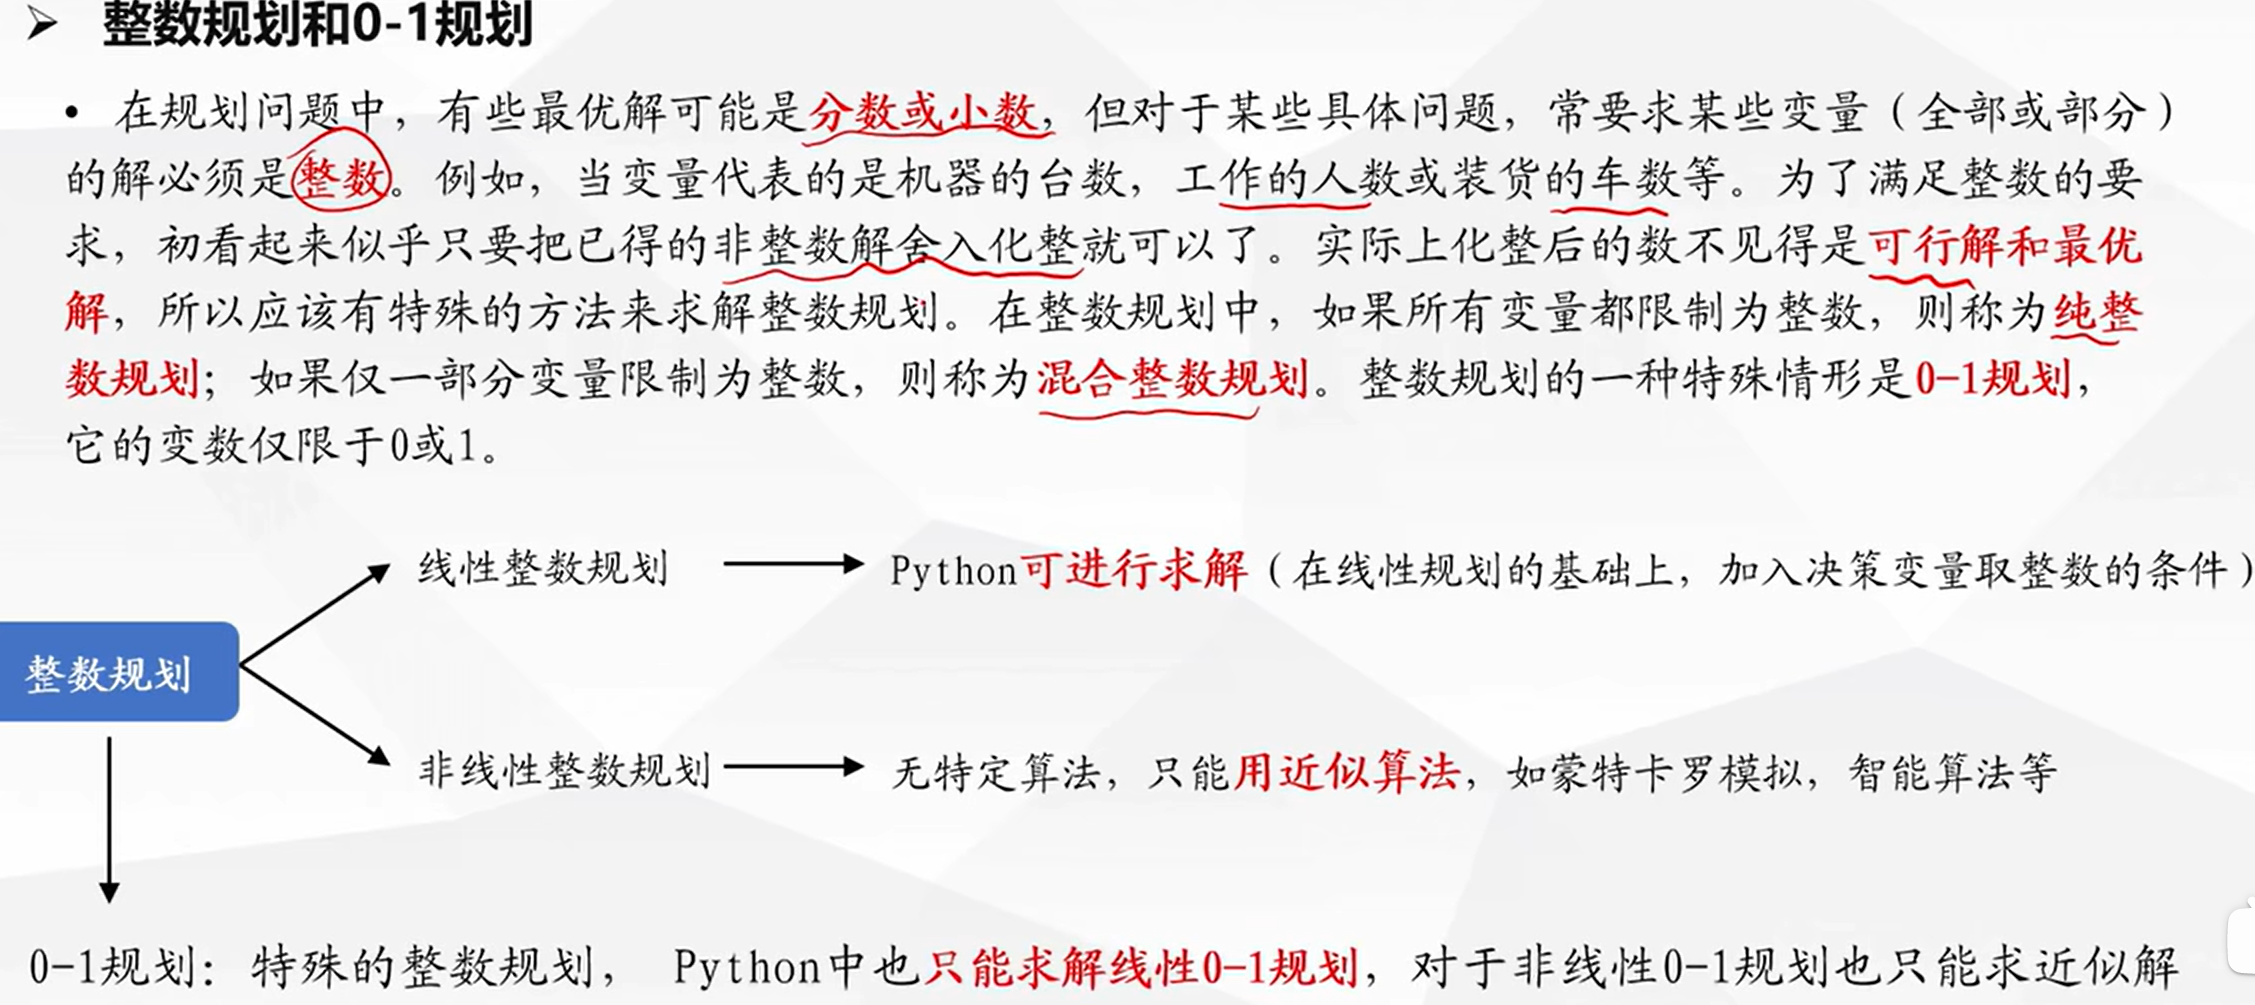

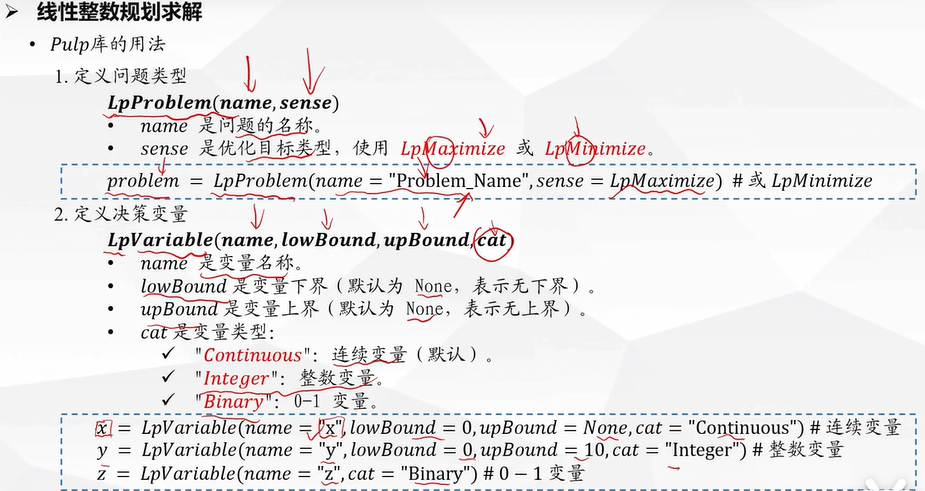

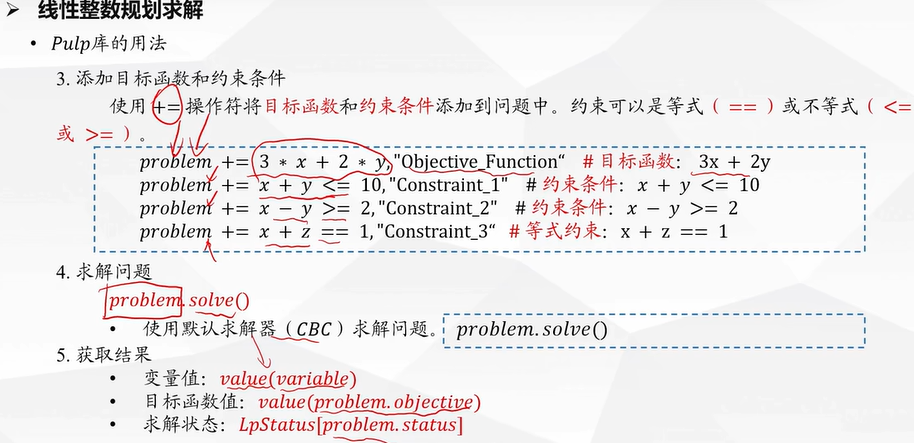

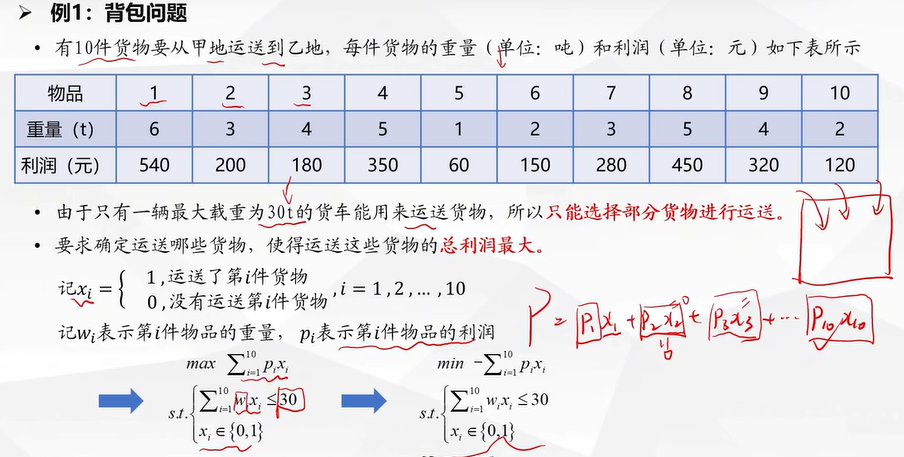

In [1]:
from pulp import LpMaximize, LpProblem, LpVariable, lpSum, value

# 创建最大化问题
problem = LpProblem(name="Knapsack_Problem", sense=LpMaximize)

# 定义目标函数系数（利润）
profits = [540, 200, 180, 350, 60, 150, 280, 450, 320, 120]

# 定义约束系数（重量）
weights = [6, 3, 4, 5, 1, 2, 3, 5, 4, 2]
max_weight = 30

# 定义决策变量（0-1变量）
x = [LpVariable(name=f"x{i+1}", cat="Binary") for i in range(10)]

# 定义目标函数（最大化总利润）
problem += lpSum(profits[i] * x[i] for i in range(10)), "Total_Profit"

# 添加约束条件（总重量不超过最大承载量）
problem += lpSum(weights[i] * x[i] for i in range(10)) <= max_weight, "Weight_Constraint"

# 求解问题
problem.solve()

# 输出结果
print("选中的物品分别为（0表示未选，1表示选中）：")
selected_items = [int(value(x[i])) for i in range(10)]
print(selected_items)

print("最终最大利润为：")
print(value(problem.objective))

选中的物品分别为（0表示未选，1表示选中）：
[1, 1, 0, 1, 0, 1, 1, 1, 1, 1]
最终最大利润为：
2410.0


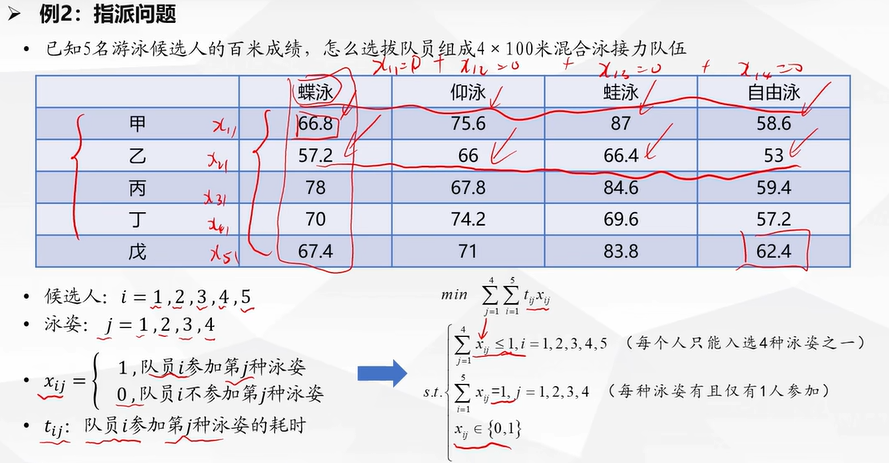

In [4]:
from pulp import LpMinimize, LpProblem, LpVariable, lpSum, value

# 创建最小化问题
problem = LpProblem(name="Assignment_Problem", sense=LpMinimize)

# 定义目标函数系数（泳姿时间）
c = [66.8, 75.6, 87, 58.6, 57.2, 66, 66.4, 53, 78, 67.8, 84.6, 59.4,
     70, 74.2, 69.6, 57.2, 67.4, 71, 83.8, 62.4]

# 定义决策变量（0-1变量）
x = [LpVariable(name=f"x{i+1}", cat="Binary") for i in range(20)]

# 定义目标函数（最小化总时间）
problem += lpSum(c[i] * x[i] for i in range(20)), "Total_Time"

# 添加不等式约束（每个人只能入选四种泳姿之一）
A = [
    [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1]
]
b = [1, 1, 1, 1, 1]

for i in range(len(A)):
    problem += lpSum(A[i][j] * x[j] for j in range(20)) <= b[i], f"Person_Constraint_{i+1}"

# 添加等式约束（每种泳姿有且仅有一人参加）
Aeq = [
    [1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0],
    [0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0],
    [0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1]
]
beq = [1, 1, 1, 1]

for i in range(len(Aeq)):
    problem += lpSum(Aeq[i][j] * x[j] for j in range(20)) == beq[i], f"Style_Constraint_{i+1}"

# 求解问题
problem.solve()

# 输出结果
assignments = [int(x[i].varValue) for i in range(20)]
print("分配结果（0表示未选，1表示选中）：")
print(assignments)

print("最终最小总时间为：", value(problem.objective))

# 可选：将结果重置为 4x5 矩阵形式，方便查看
import numpy as np
assignment_matrix = np.array(assignments).reshape(5, 4)
print("分配矩阵（行对应泳姿，列对应队员）：")
print(assignment_matrix)

分配结果（0表示未选，1表示选中）：
[0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]
最终最小总时间为： 253.20000000000002
分配矩阵（行对应泳姿，列对应队员）：
[[0 0 0 1]
 [1 0 0 0]
 [0 1 0 0]
 [0 0 1 0]
 [0 0 0 0]]
